In [ ]:
"EDA"

In [60]:
import pandas as pd
raw_dir = "../data/raw/"
processed_dir = "../data/processed/"
w = pd.read_csv(processed_dir + "analysis_ready_weekly.csv")

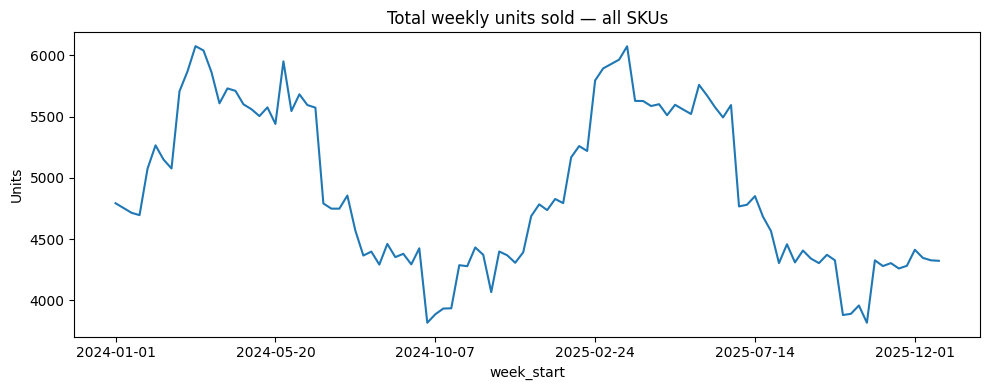

In [61]:
# --- overall weekly demand trend ---
from matplotlib import pyplot as plt
total = w.groupby("week_start")["units_sold"].sum()
plt.figure(figsize=(10, 4))
total.plot()
plt.title("Total weekly units sold — all SKUs")
plt.ylabel("Units")
plt.tight_layout()
plt.show()
plt.close()

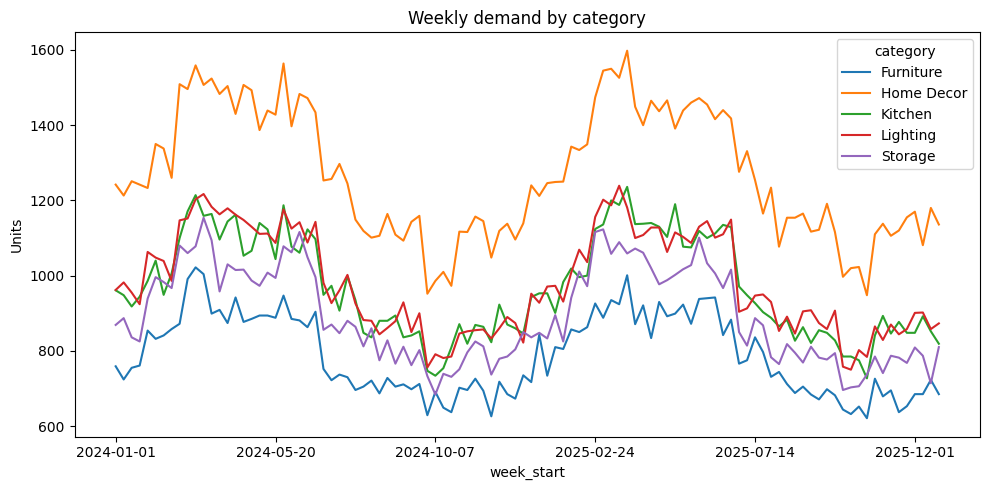

In [62]:
# --- demand by category ---
from matplotlib import pyplot as plt
cat = w.groupby(["week_start", "category"])["units_sold"].sum().unstack()
plt.figure(figsize=(10, 5))
cat.plot(ax=plt.gca())
plt.title("Weekly demand by category")
plt.ylabel("Units")
plt.tight_layout()
plt.show()
plt.close()

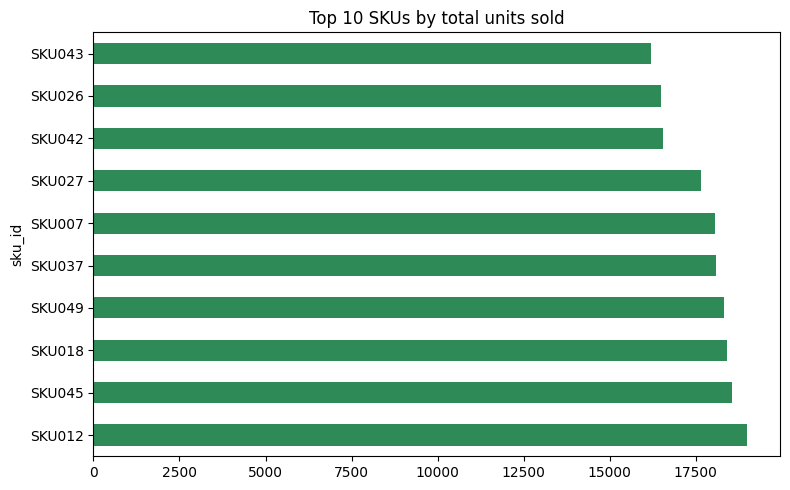

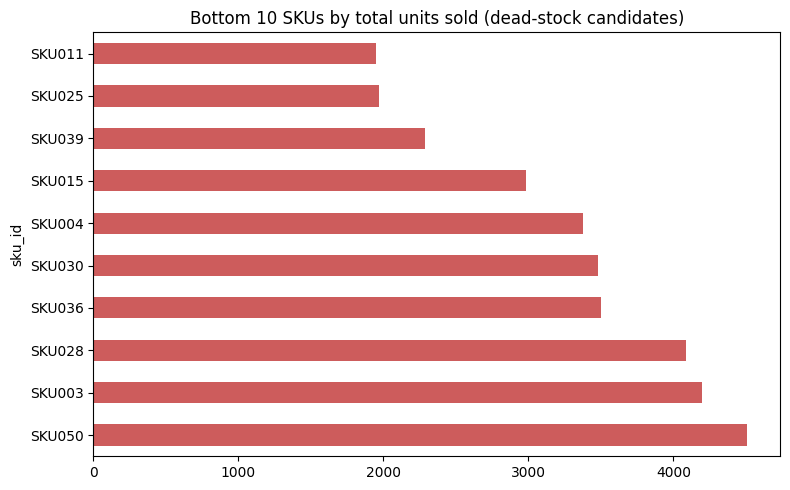

In [17]:
 # --- top movers / dead stock ---
sku_totals = w.groupby("sku_id")["units_sold"].sum().sort_values(ascending=False)
top10 = sku_totals.head(10)
bottom10 = sku_totals.tail(10)

plt.figure(figsize=(8, 5))
top10.plot(kind="barh", color="seagreen")
plt.title("Top 10 SKUs by total units sold")
plt.tight_layout()
plt.show()
plt.close()

plt.figure(figsize=(8, 5))
bottom10.plot(kind="barh", color="indianred")
plt.title("Bottom 10 SKUs by total units sold (dead-stock candidates)")
plt.tight_layout()
plt.show()
plt.close()

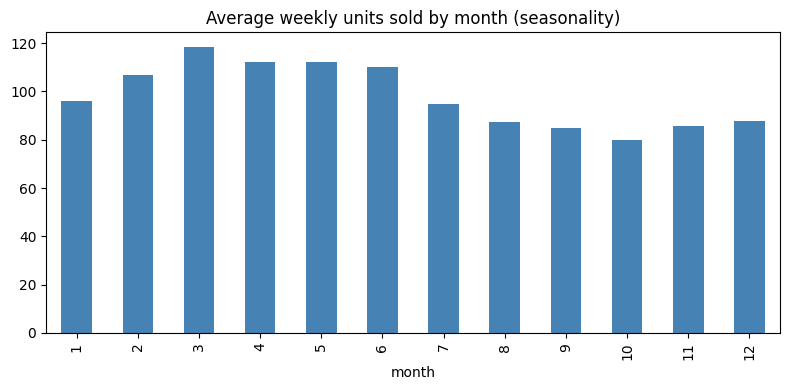

In [21]:
# --- seasonality ---
w["week_start"] = pd.to_datetime(w["week_start"])
w["month"] = w["week_start"].dt.month
seasonal = w.groupby("month")["units_sold"].mean()
plt.figure(figsize=(8, 4))
seasonal.plot(kind="bar", color="steelblue")
plt.title("Average weekly units sold by month (seasonality)")
plt.tight_layout()
plt.show()
plt.close()

In [37]:
# --- promo effect ---
promo_effect = w.groupby("promo_flag")["units_sold"].mean()
print(f"Average Units Sold due to promotion {promo_effect[1]:.0f} units")
print(f"Average Units Sold on no promotion {promo_effect[0]:.0f} units")

Average Units Sold due to promotion 101 units
Average Units Sold on no promotion 96 units


In [38]:
# --- holiday effect ---
holiday_effect = w.groupby("is_holiday")["units_sold"].mean()
print(f"Average sale on holidays {holiday_effect[1]:.0f} units")
print(f"Average sale on non holidays {holiday_effect[0]:.0f} units")

Average sale on holidays 88 units
Average sale on non holidays 99 units


In [39]:
# --- coefficient of variation per SKU (volatility) ---
cv = w.groupby("sku_id")["units_sold"].agg(["mean", "std"])
cv["cv"] = cv["std"] / cv["mean"]
most_volatile = cv.sort_values("cv", ascending=False).head(5)
print(most_volatile)

             mean       std        cv
sku_id                               
SKU011  18.730769  4.958529  0.264726
SKU025  18.932692  4.791304  0.253070
SKU039  22.000000  5.436304  0.247105
SKU036  33.644231  7.735830  0.229930
SKU050  43.365385  9.654274  0.222626


In [43]:
# Build the insight memo
# Year-over-year on the same calendar weeks (avoids mistaking seasonality for a trend)
total = w.groupby("week_start")["units_sold"].sum()
y24, y25 = total[total.index.year == 2024], total[total.index.year == 2025]
n = min(len(y24), len(y25))
print(n)
print(y25.iloc[:n].sum())
growth_pct = (y25.iloc[:n].sum() / y24.iloc[:n].sum() - 1) * 100
print(growth_pct)

51
250066
-0.34670194790703546
